# Summary statistics from ClonalOrigin seq and pair models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import Phylo
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree

torch_device = "cpu"

## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(30, 1000000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=30)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                    ____ 14
                                                                   |
                                                                   |    , 15
                                                        ___________|   _|
                                                       |           |  | , 5
                                                       |           |  | |
                                                       |           |__| | 24
                                                       |              |
                                                       |              | , 27
                                                       |              |_|
                                                       |                | 4
                                                       |
                                                       |      __________ 18
                                             

## Summary statistics

### Get summary statistics from SimBac data

In [5]:
x_500_mat = np.loadtxt("../data/x_500_SB.csv", delimiter=",")
x_2000_mat = np.loadtxt("../data/x_2000_SB.csv", delimiter=",")
x_6000_mat = np.loadtxt("../data/x_6000_SB.csv", delimiter=",")

x_500_mat.shape, x_2000_mat.shape, x_6000_mat.shape

((100, 46), (100, 46), (100, 46))

### Summary statistics from ClonalOrigin seq model

In this section, we plot the summary statistics changing by one model parameter each time. When unchanged, the parameters were $\rho_s = 0.02$, $\theta_s = 0.05$, and $L = 2000$.

In [6]:
x_seq = np.loadtxt('../data/x_seq.csv', delimiter=",")
rho_seq = np.loadtxt('../data/rho_site_seq.csv', delimiter=",")
theta_seq = np.loadtxt('../data/theta_site_seq.csv', delimiter=",")
L_seq = np.loadtxt('../data/L_seq.csv', delimiter=",")
x_seq.shape, rho_seq.shape, theta_seq.shape, L_seq.shape

((200, 4), (200, 46), (200, 46), (200, 46))

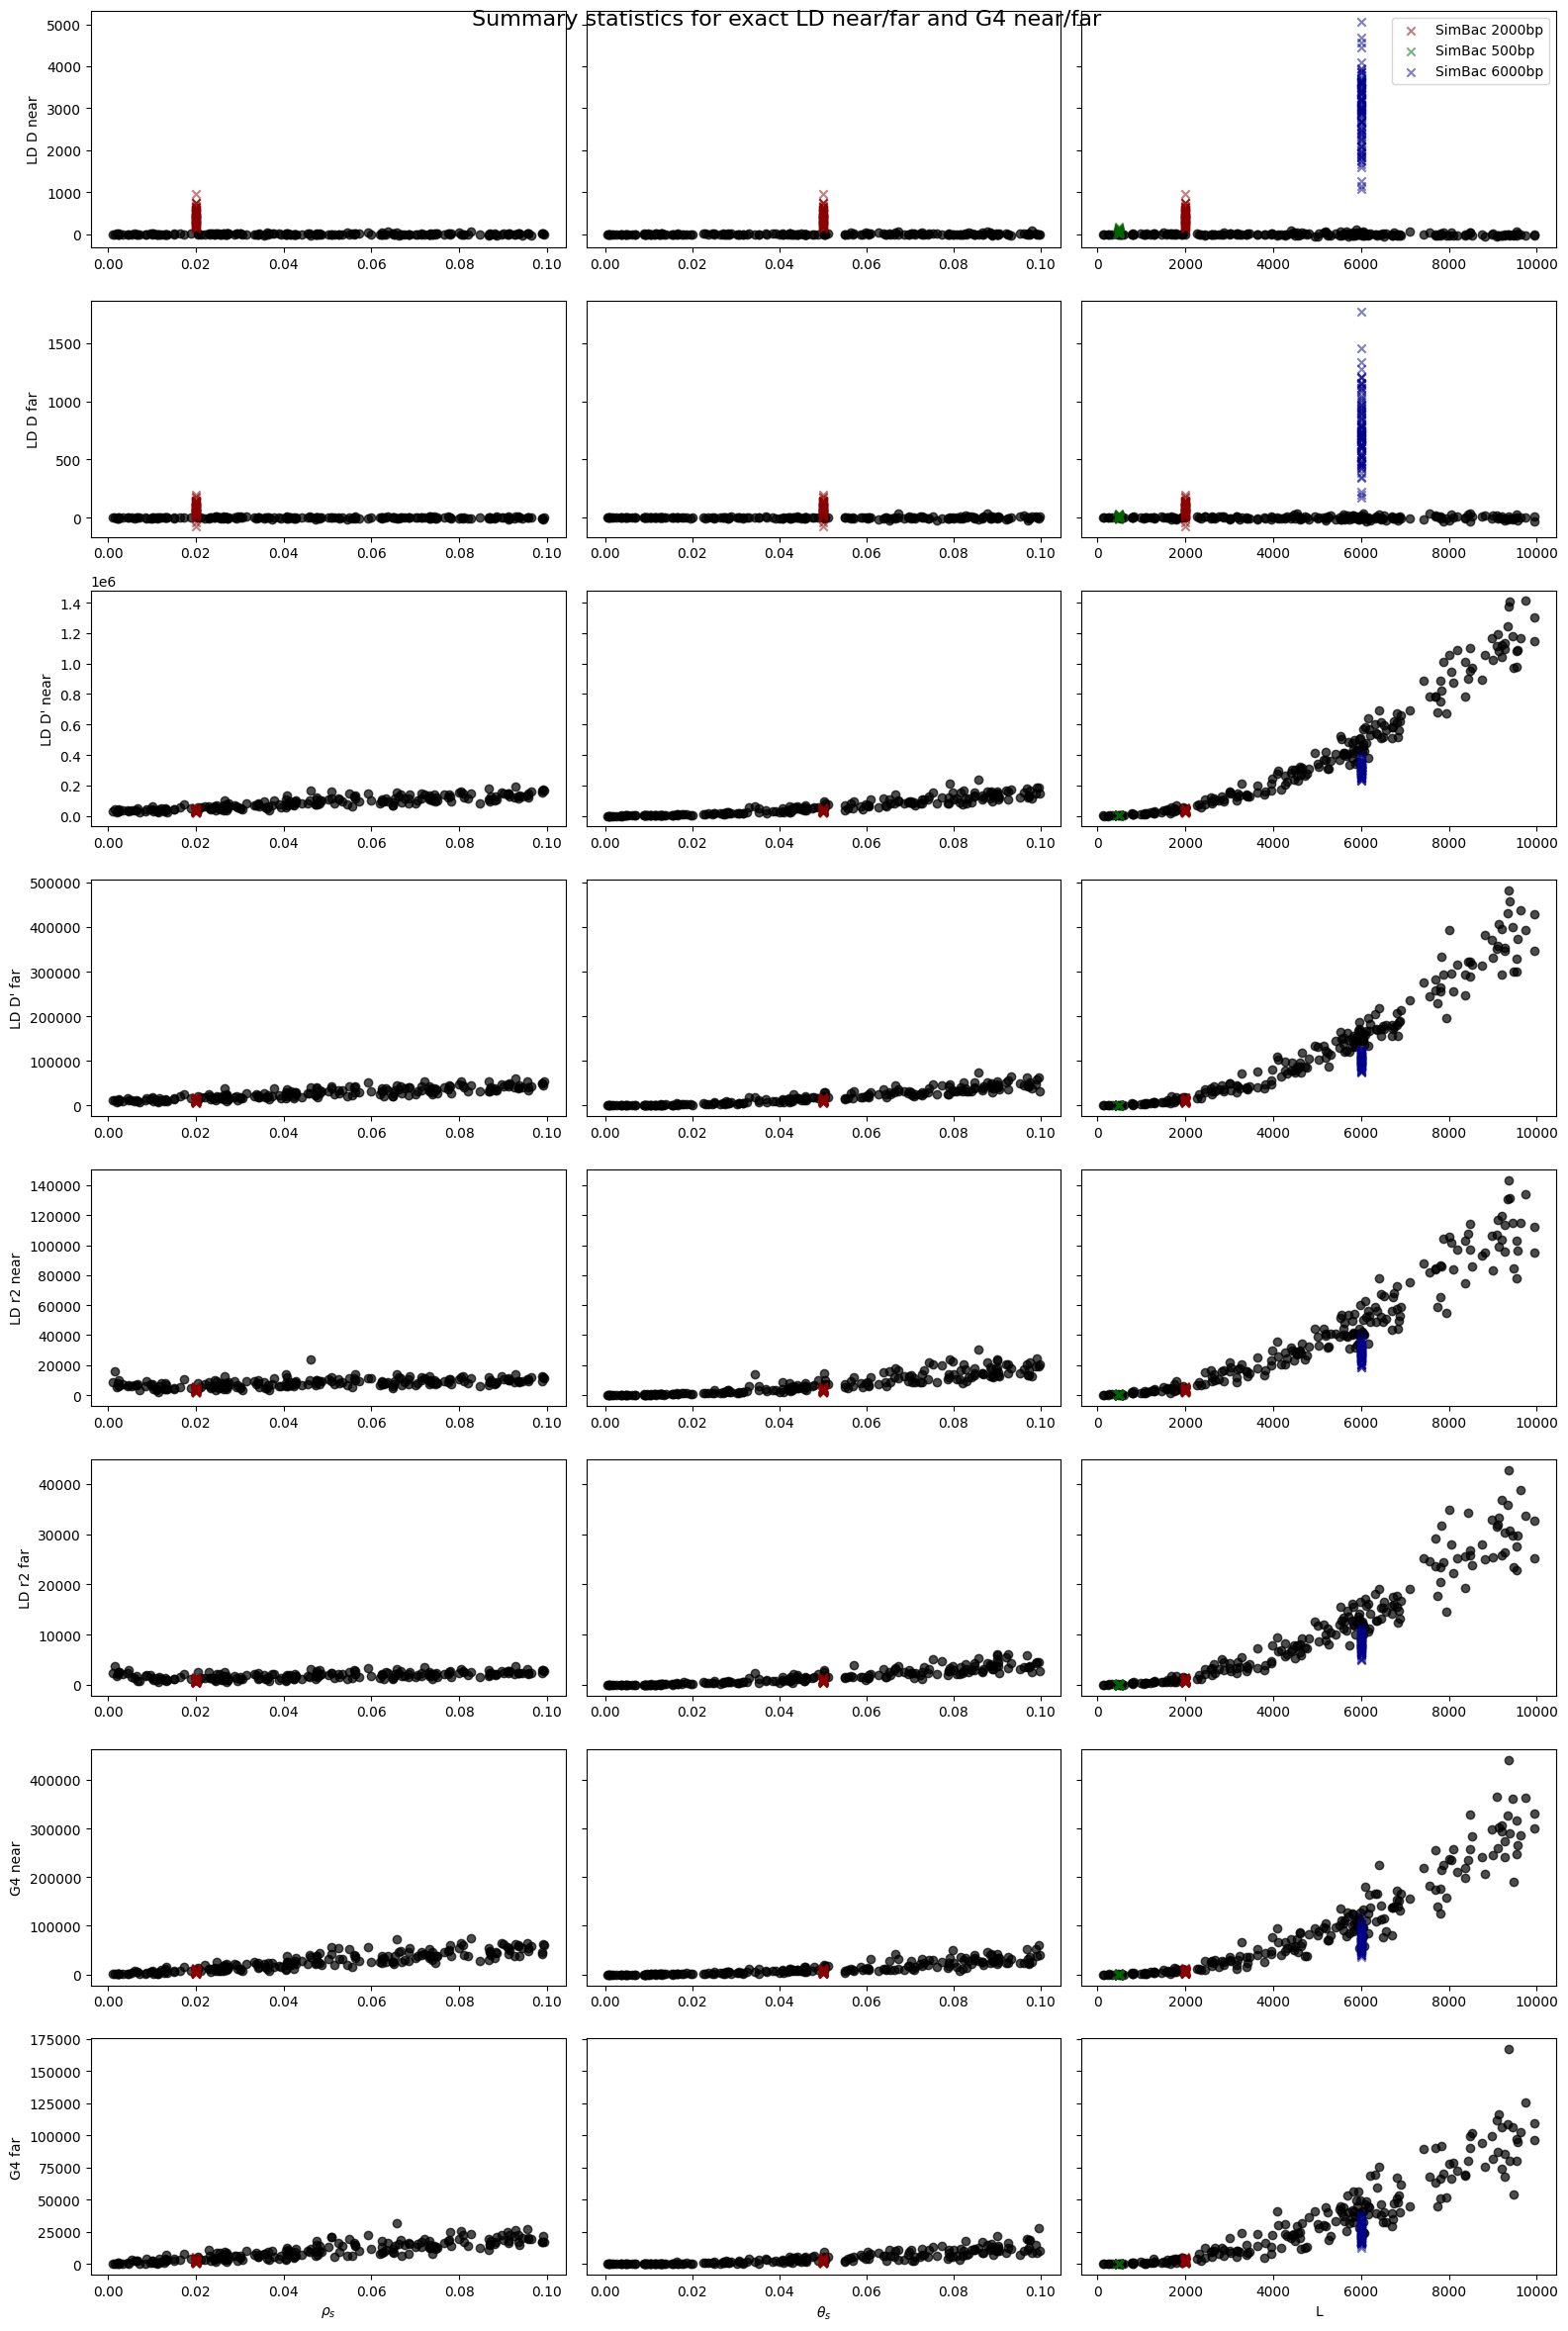

In [7]:
fig, axs = plt.subplots(8, 3, figsize=(16, 24), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(8):
        axs[row, col].scatter(x_var, y_mat[:, row], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[7, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(8):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('LD D near')
axs[1, 0].set_ylabel('LD D far')
axs[2, 0].set_ylabel('LD D\' near')
axs[3, 0].set_ylabel('LD D\' far')
axs[4, 0].set_ylabel('LD r2 near')
axs[5, 0].set_ylabel('LD r2 far')
axs[6, 0].set_ylabel('G4 near')
axs[7, 0].set_ylabel('G4 far')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for exact LD near/far and G4 near/far', fontsize=16)
plt.tight_layout()
plt.show()

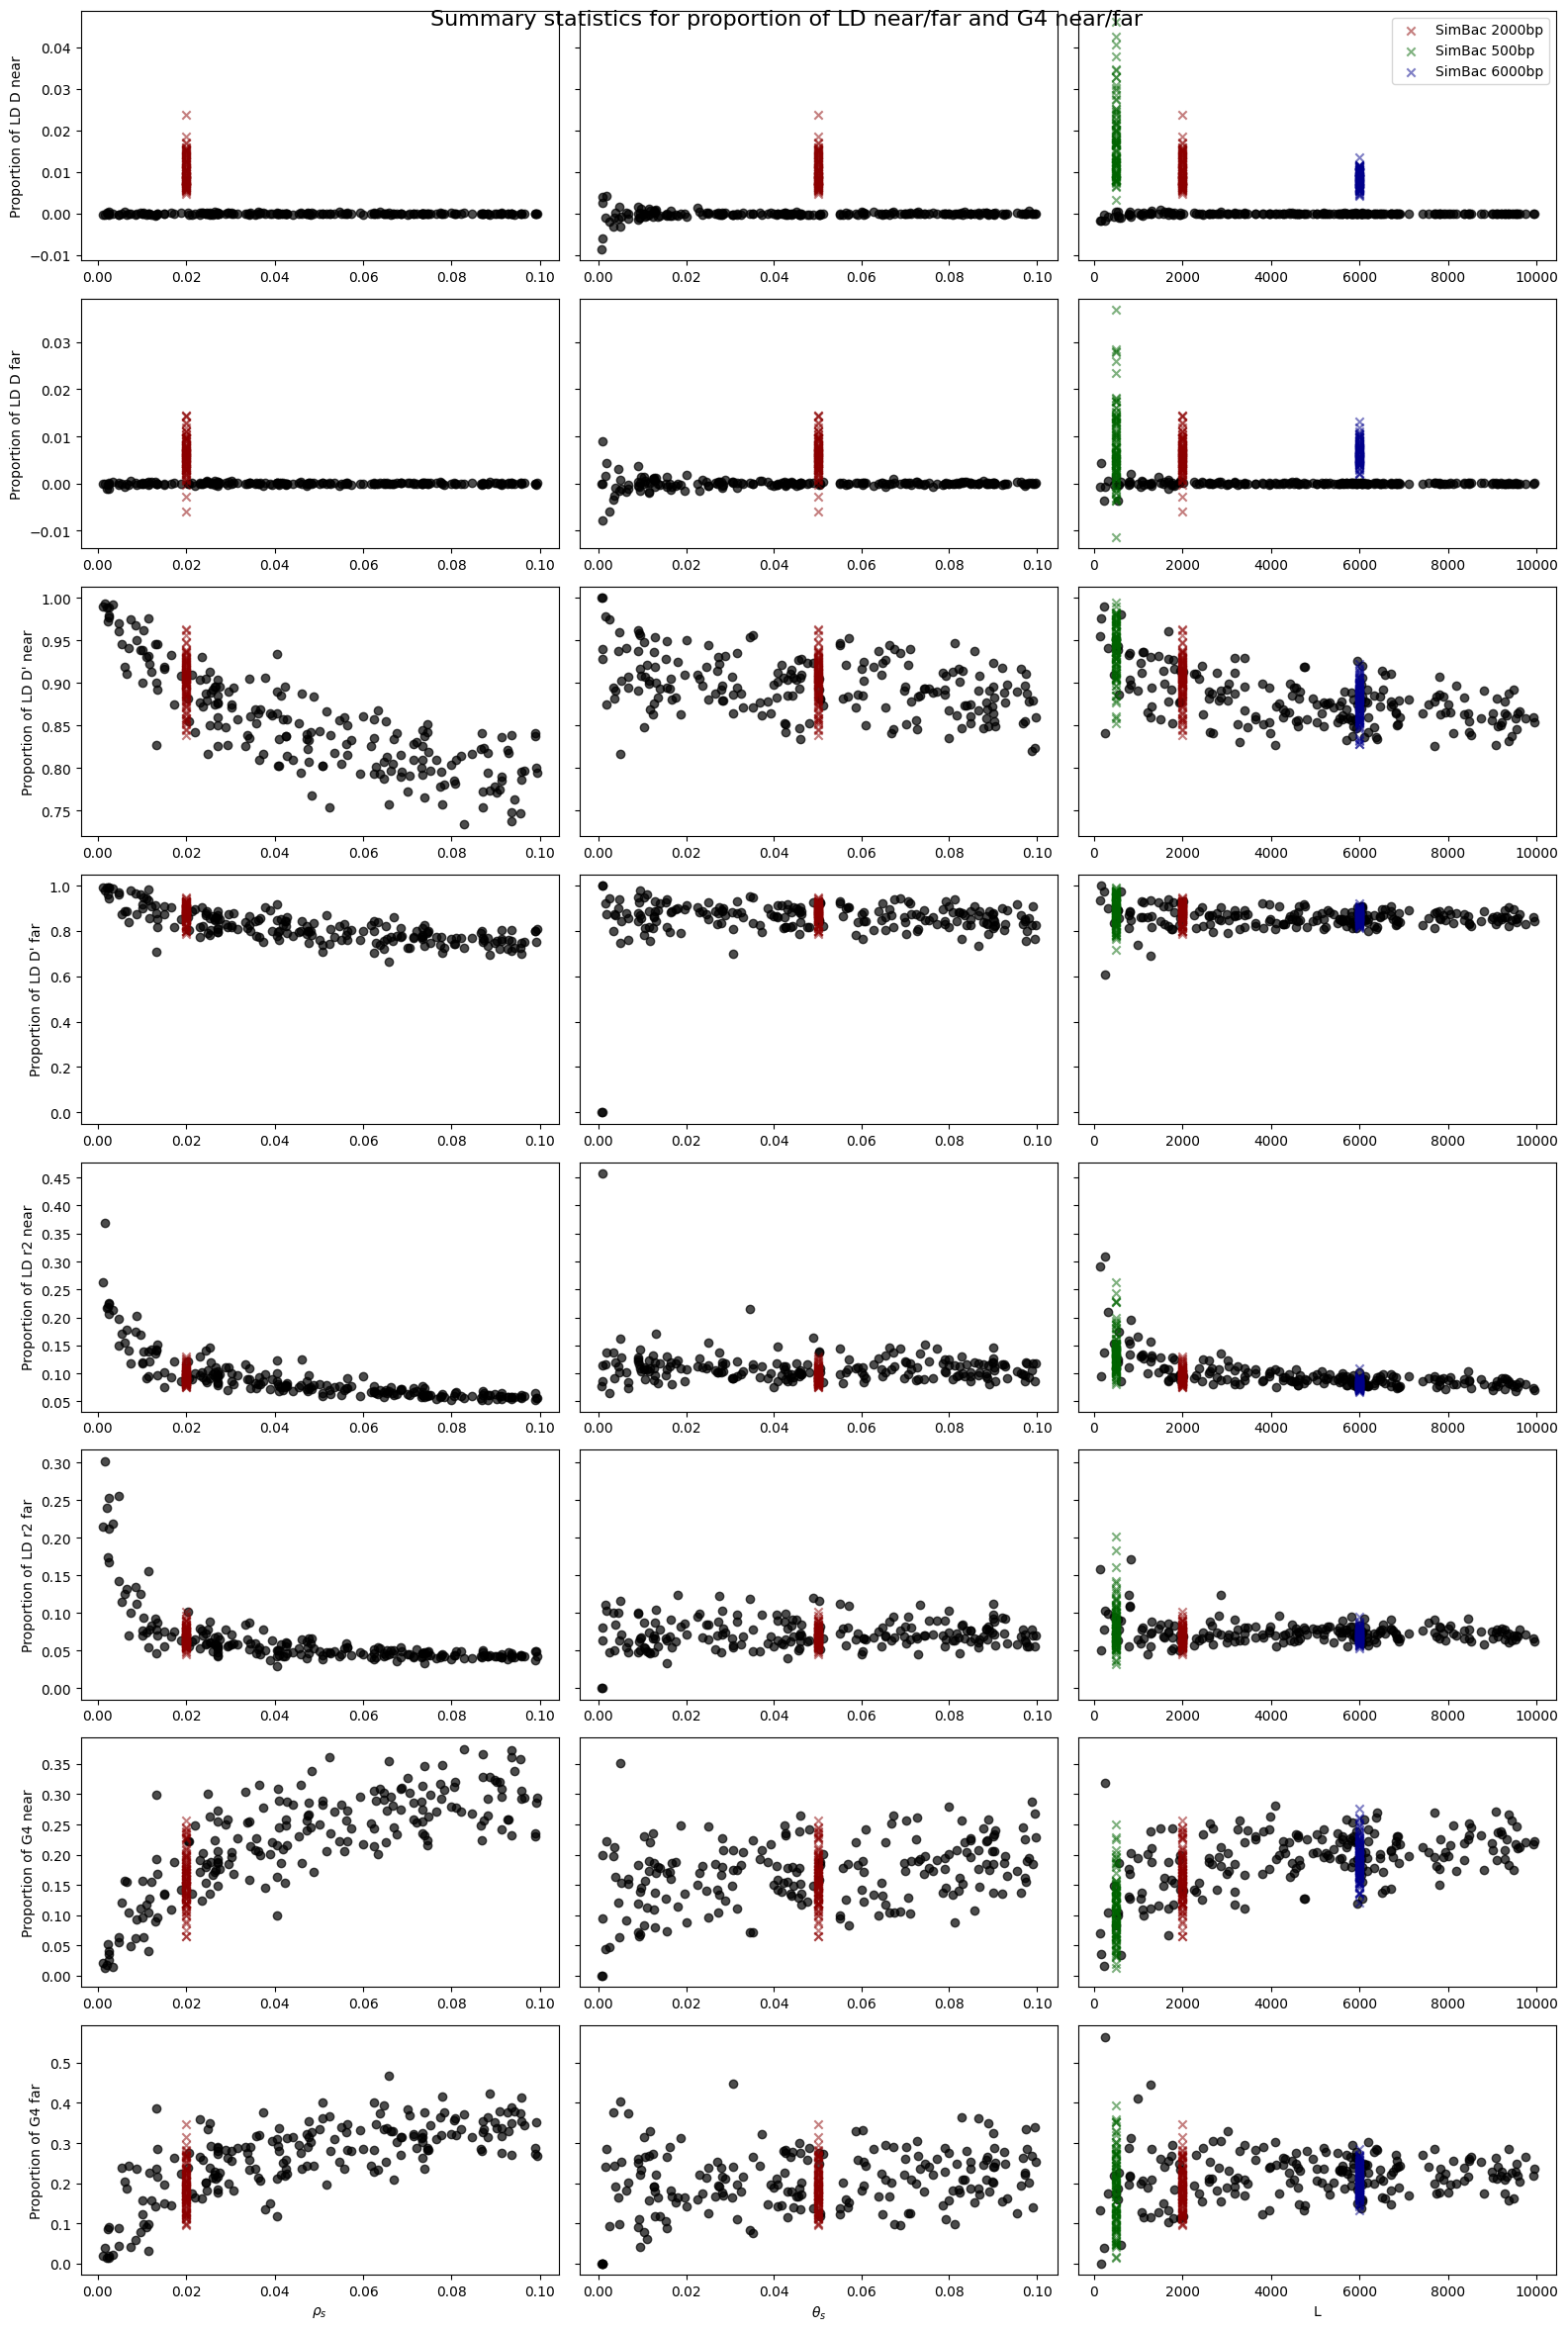

In [8]:
fig, axs = plt.subplots(8, 3, figsize=(16, 24), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(8):
        axs[row, col].scatter(x_var, y_mat[:, row+8], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+8], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[7, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(8):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+8], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+8], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Proportion of LD D near')
axs[1, 0].set_ylabel('Proportion of LD D far')
axs[2, 0].set_ylabel('Proportion of LD D\' near')
axs[3, 0].set_ylabel('Proportion of LD D\' far')
axs[4, 0].set_ylabel('Proportion of LD r2 near')
axs[5, 0].set_ylabel('Proportion of LD r2 far')
axs[6, 0].set_ylabel('Proportion of G4 near')
axs[7, 0].set_ylabel('Proportion of G4 far')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for proportion of LD near/far and G4 near/far', fontsize=16)
plt.tight_layout()
plt.show()

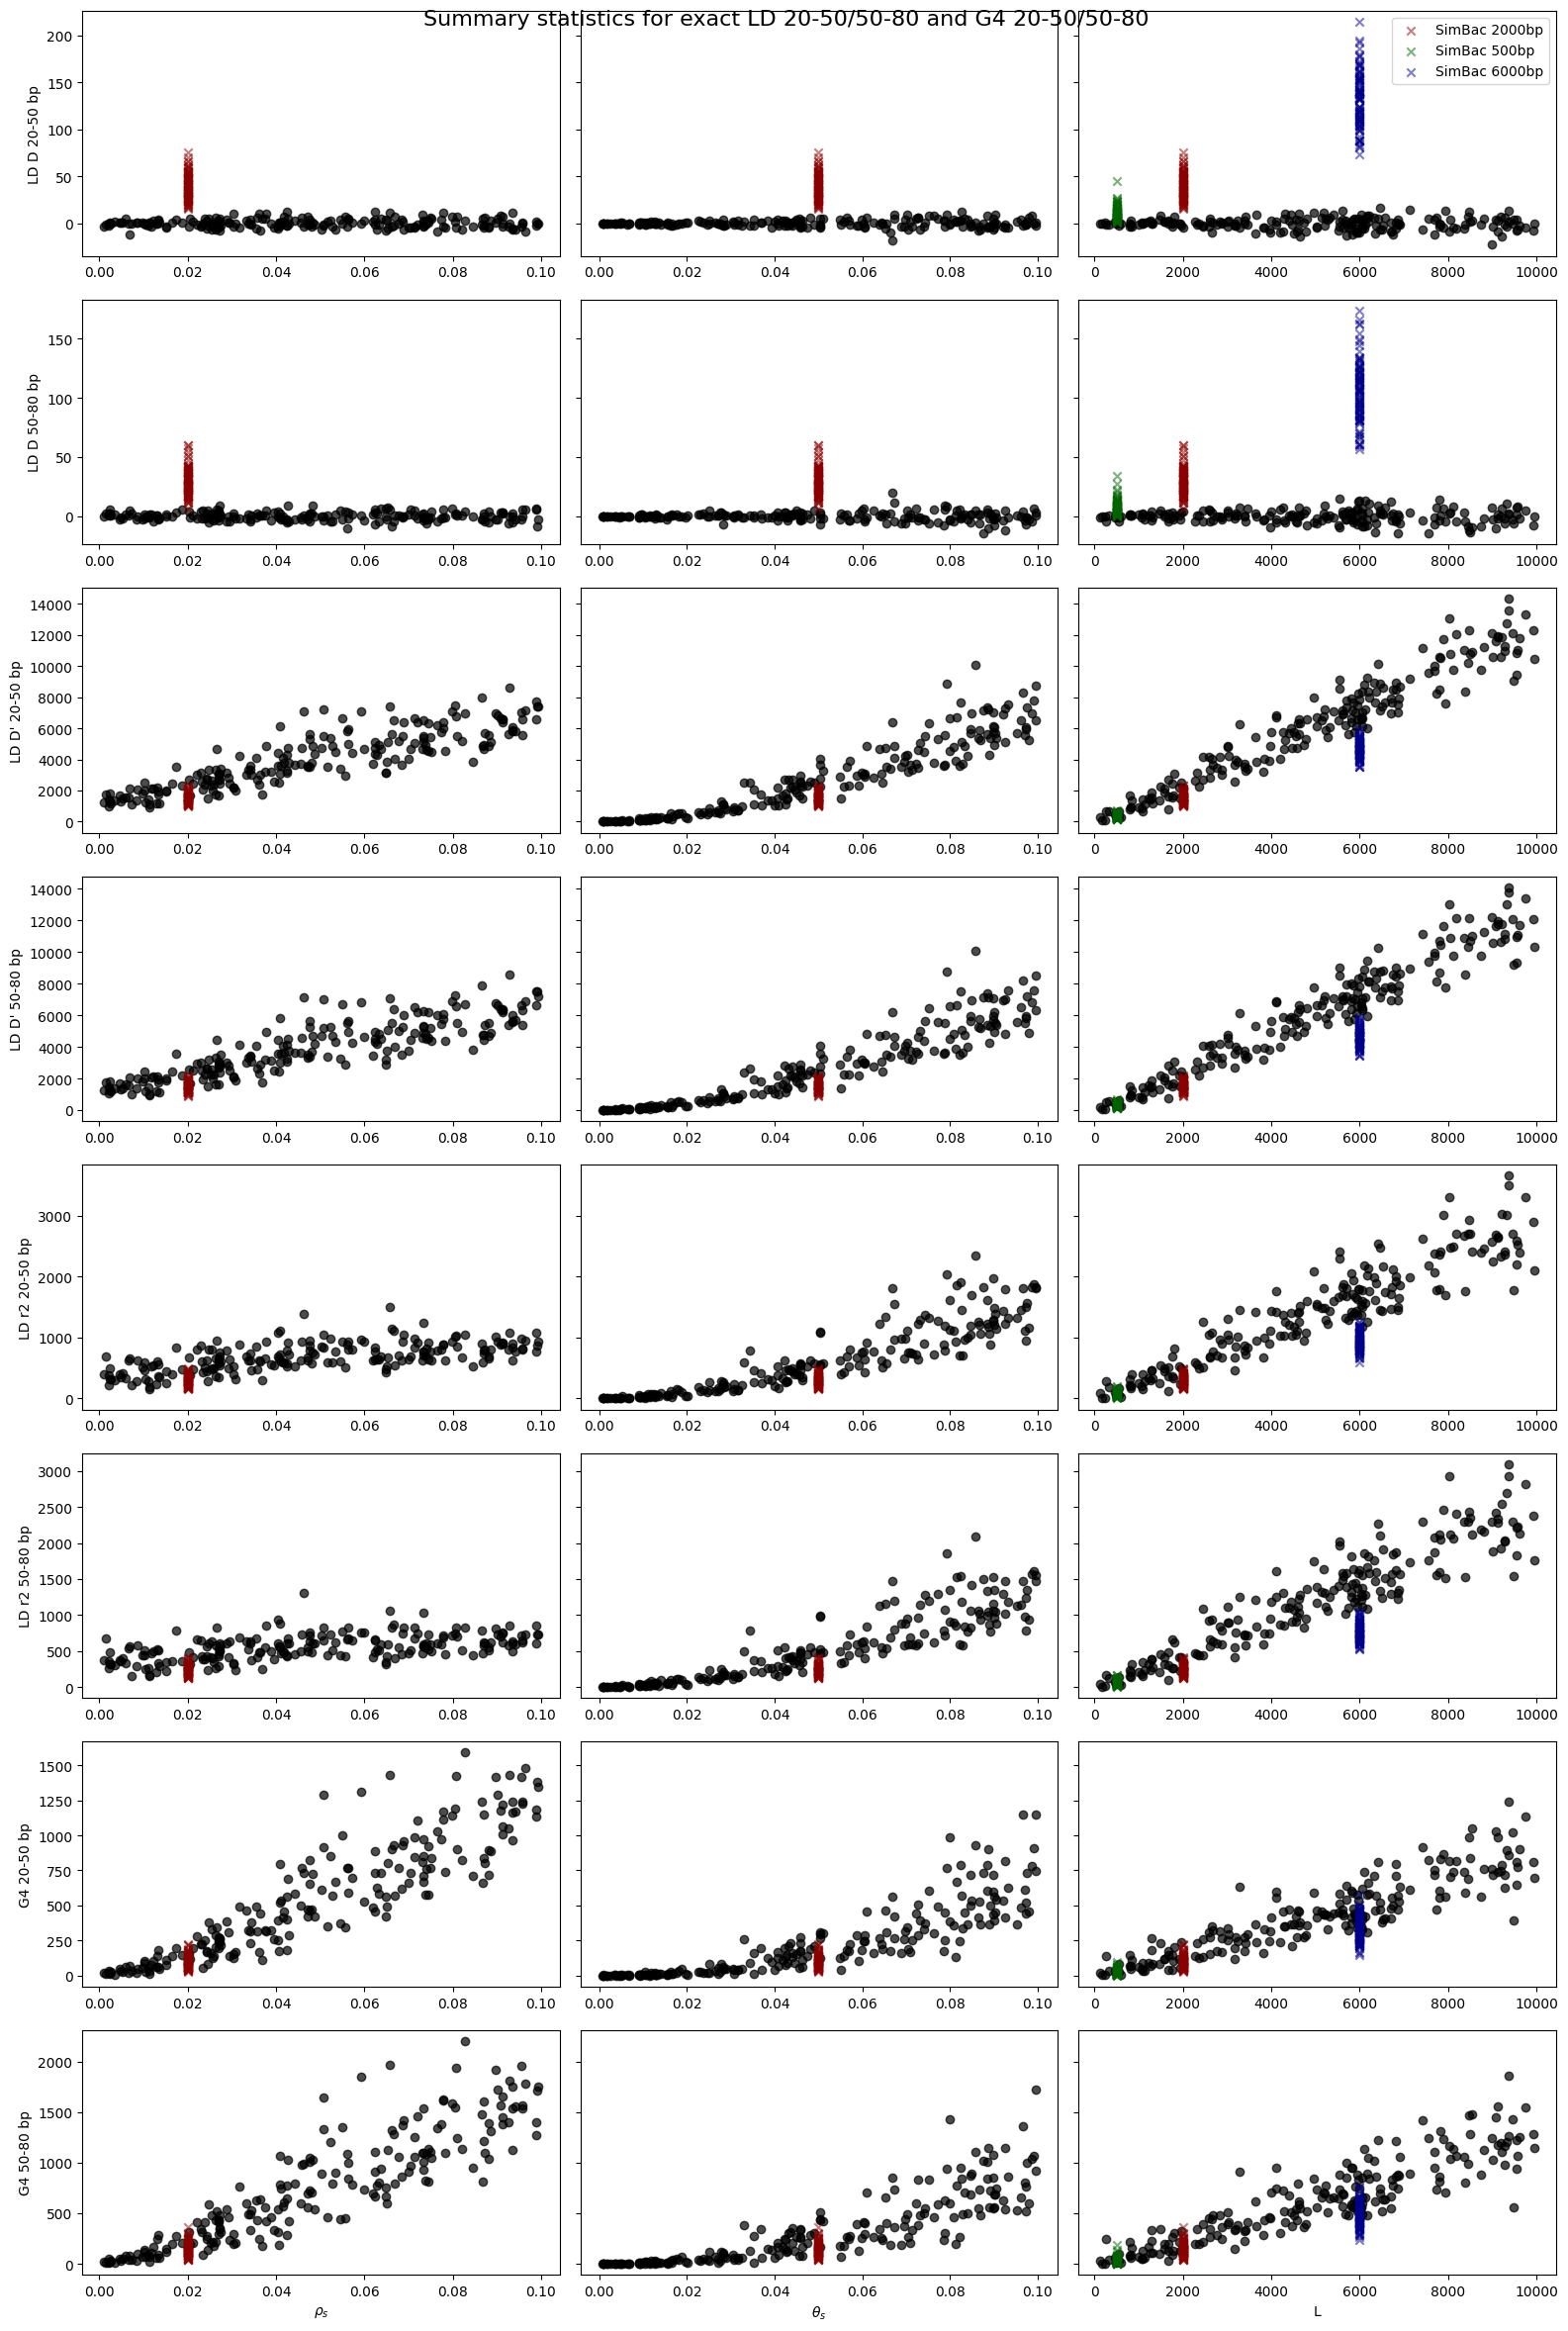

In [9]:
fig, axs = plt.subplots(8, 3, figsize=(16, 24), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(8):
        axs[row, col].scatter(x_var, y_mat[:, row+16], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+16], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[7, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(8):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+16], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+16], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('LD D 20-50 bp')
axs[1, 0].set_ylabel('LD D 50-80 bp')
axs[2, 0].set_ylabel('LD D\' 20-50 bp')
axs[3, 0].set_ylabel('LD D\' 50-80 bp')
axs[4, 0].set_ylabel('LD r2 20-50 bp')
axs[5, 0].set_ylabel('LD r2 50-80 bp')
axs[6, 0].set_ylabel('G4 20-50 bp')
axs[7, 0].set_ylabel('G4 50-80 bp')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for exact LD 20-50/50-80 and G4 20-50/50-80', fontsize=16)
plt.tight_layout()
plt.show()

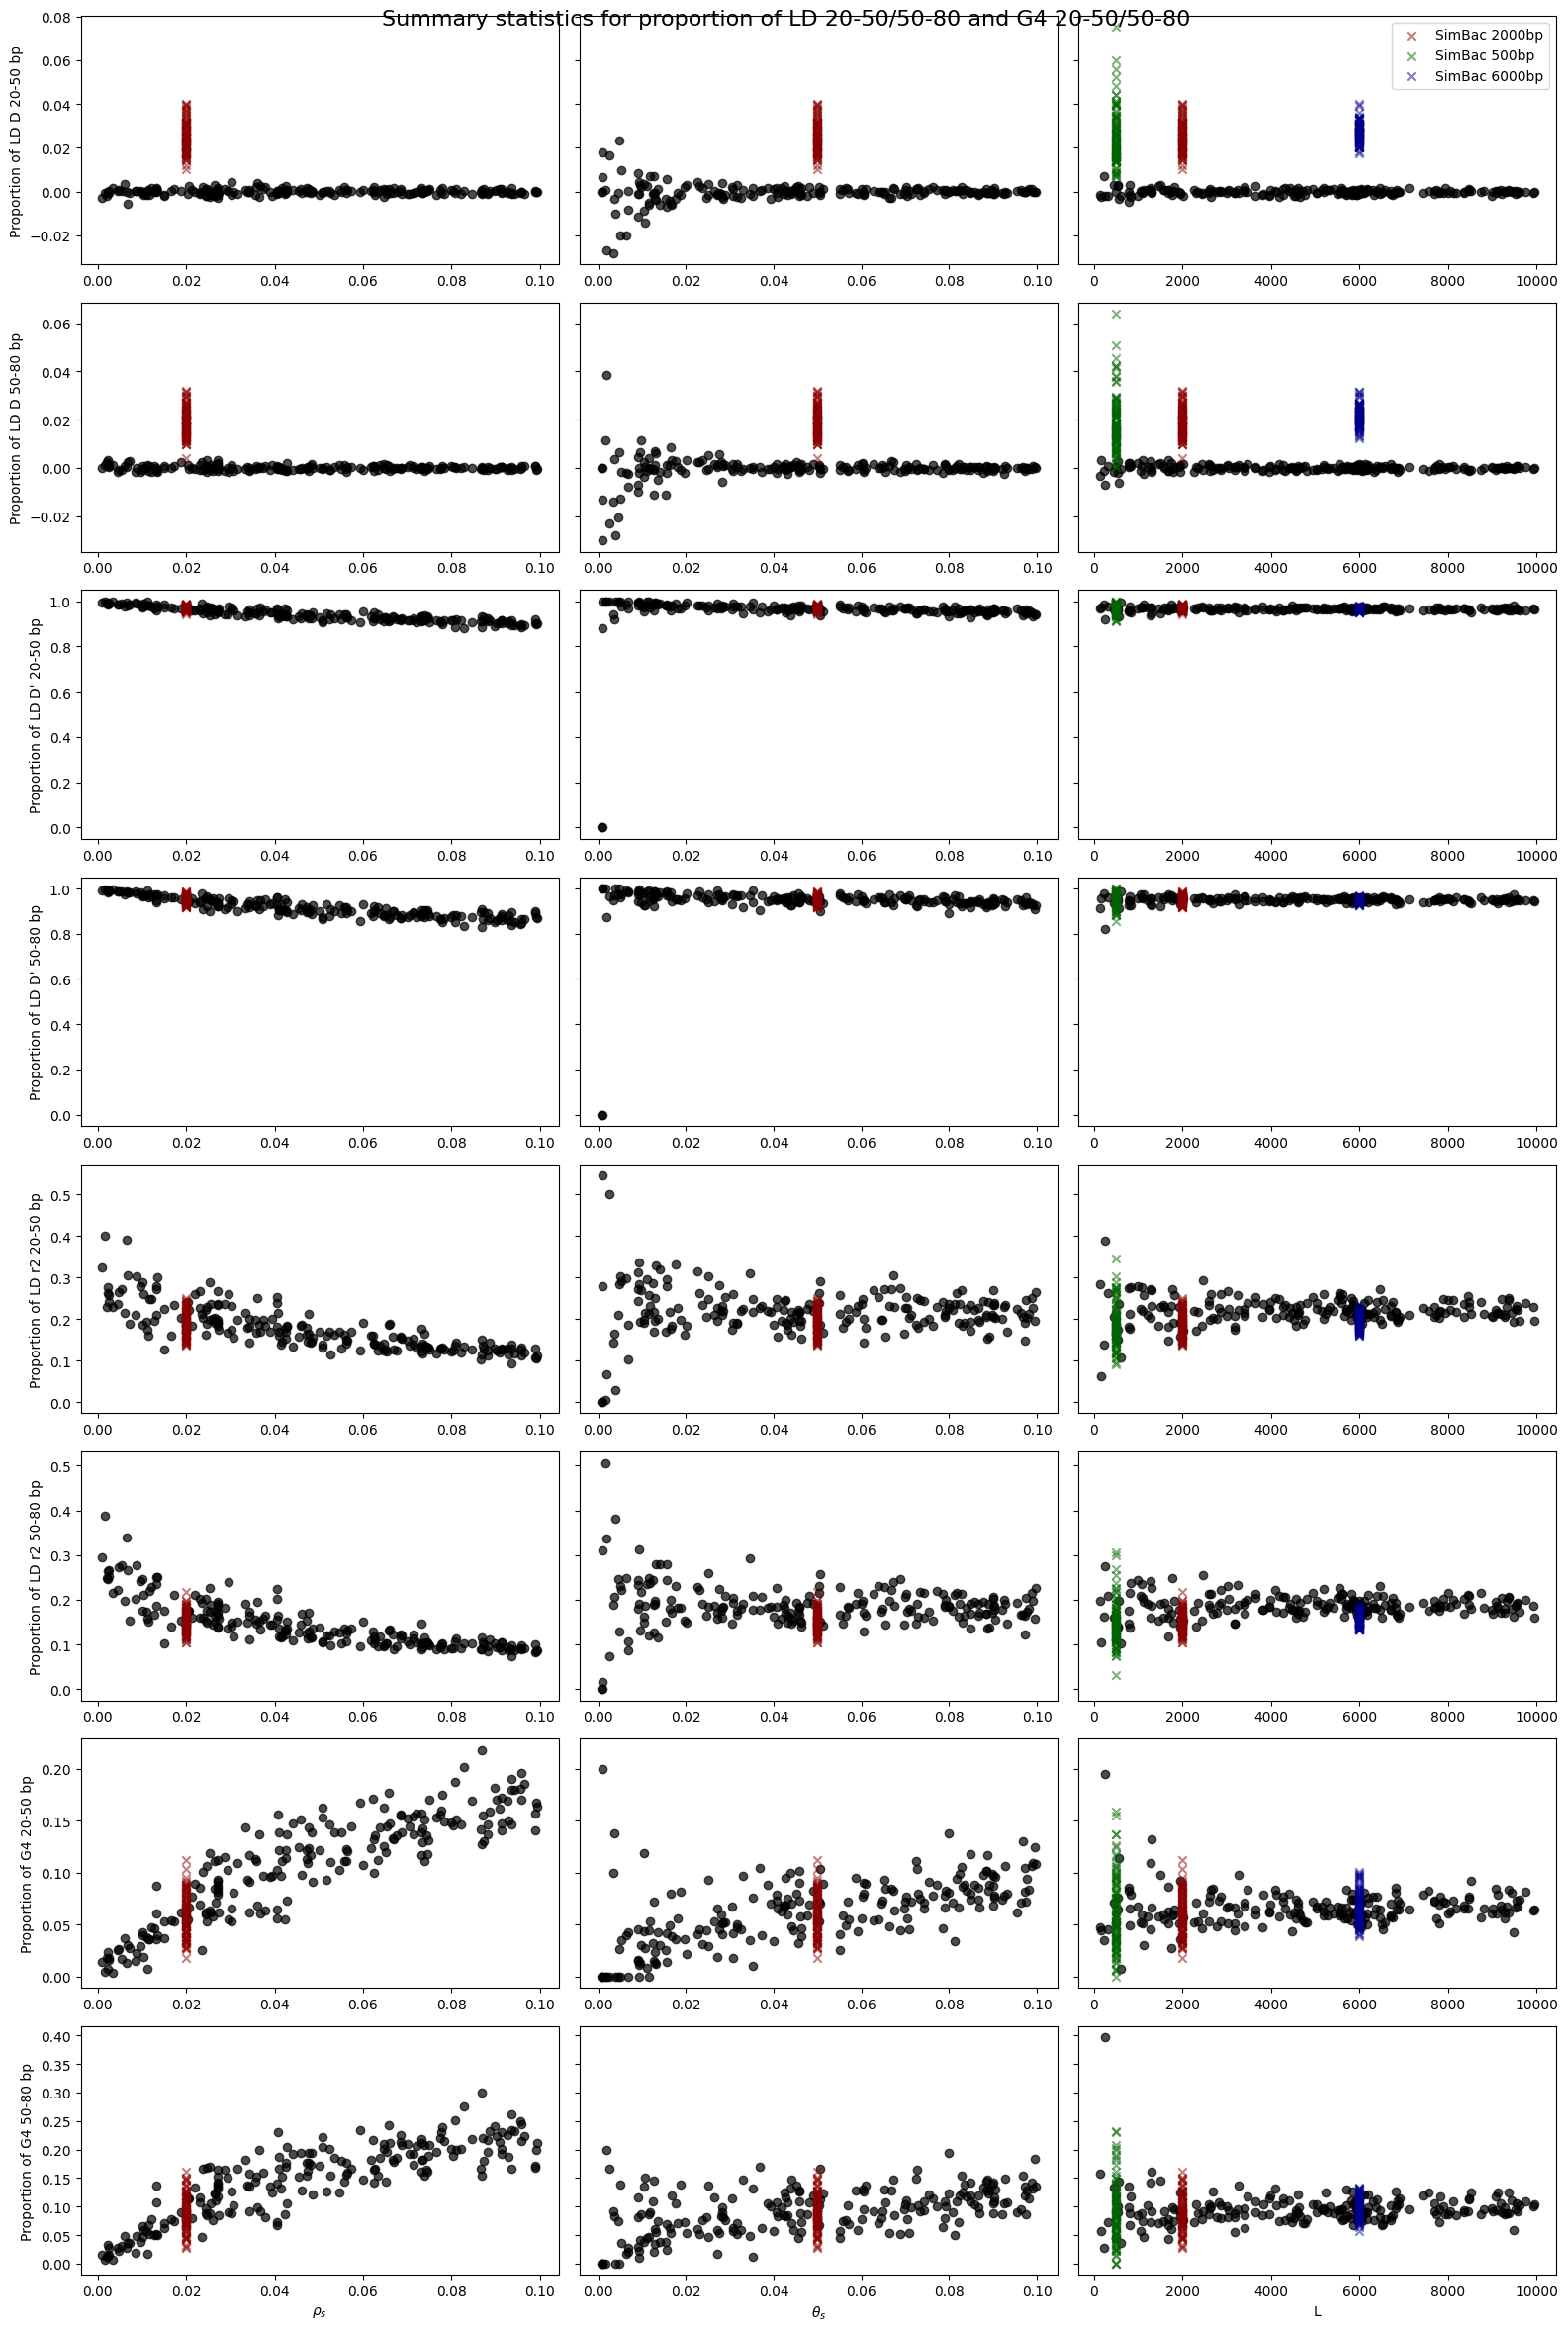

In [10]:
fig, axs = plt.subplots(8, 3, figsize=(16, 24), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(8):
        axs[row, col].scatter(x_var, y_mat[:, row+24], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+24], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[7, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(8):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+24], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+24], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Proportion of LD D 20-50 bp')
axs[1, 0].set_ylabel('Proportion of LD D 50-80 bp')
axs[2, 0].set_ylabel('Proportion of LD D\' 20-50 bp')
axs[3, 0].set_ylabel('Proportion of LD D\' 50-80 bp')
axs[4, 0].set_ylabel('Proportion of LD r2 20-50 bp')
axs[5, 0].set_ylabel('Proportion of LD r2 50-80 bp')
axs[6, 0].set_ylabel('Proportion of G4 20-50 bp')
axs[7, 0].set_ylabel('Proportion of G4 50-80 bp')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for proportion of LD 20-50/50-80 and G4 20-50/50-80', fontsize=16)
plt.tight_layout()
plt.show()

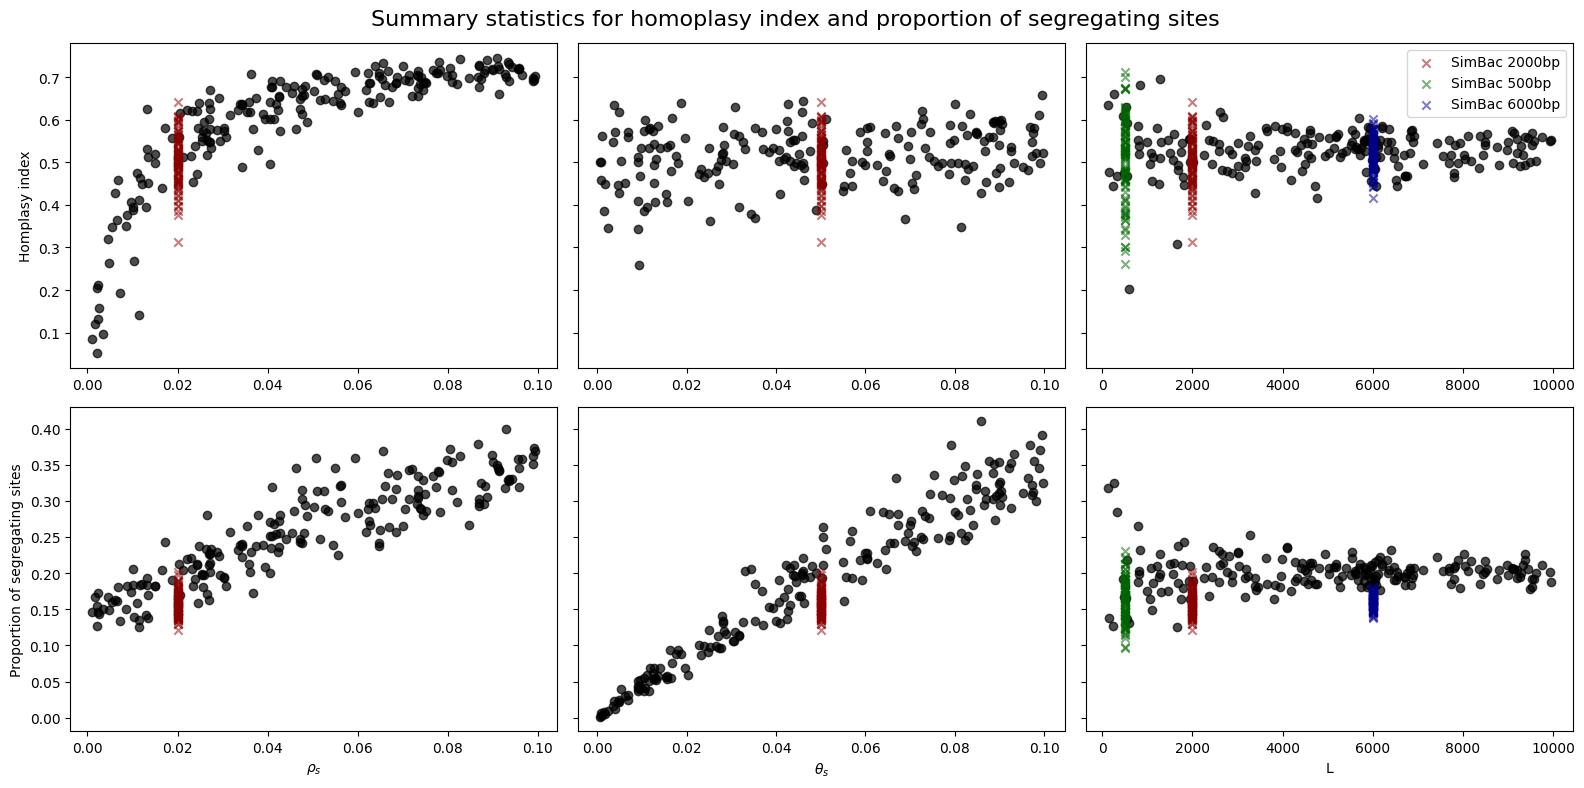

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(2):
        axs[row, col].scatter(x_var, y_mat[:, row+32], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+32], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[1, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(2):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+32], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+32], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Homplasy index')
axs[1, 0].set_ylabel('Proportion of segregating sites')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for homoplasy index and proportion of segregating sites', fontsize=16)
plt.tight_layout()
plt.show()

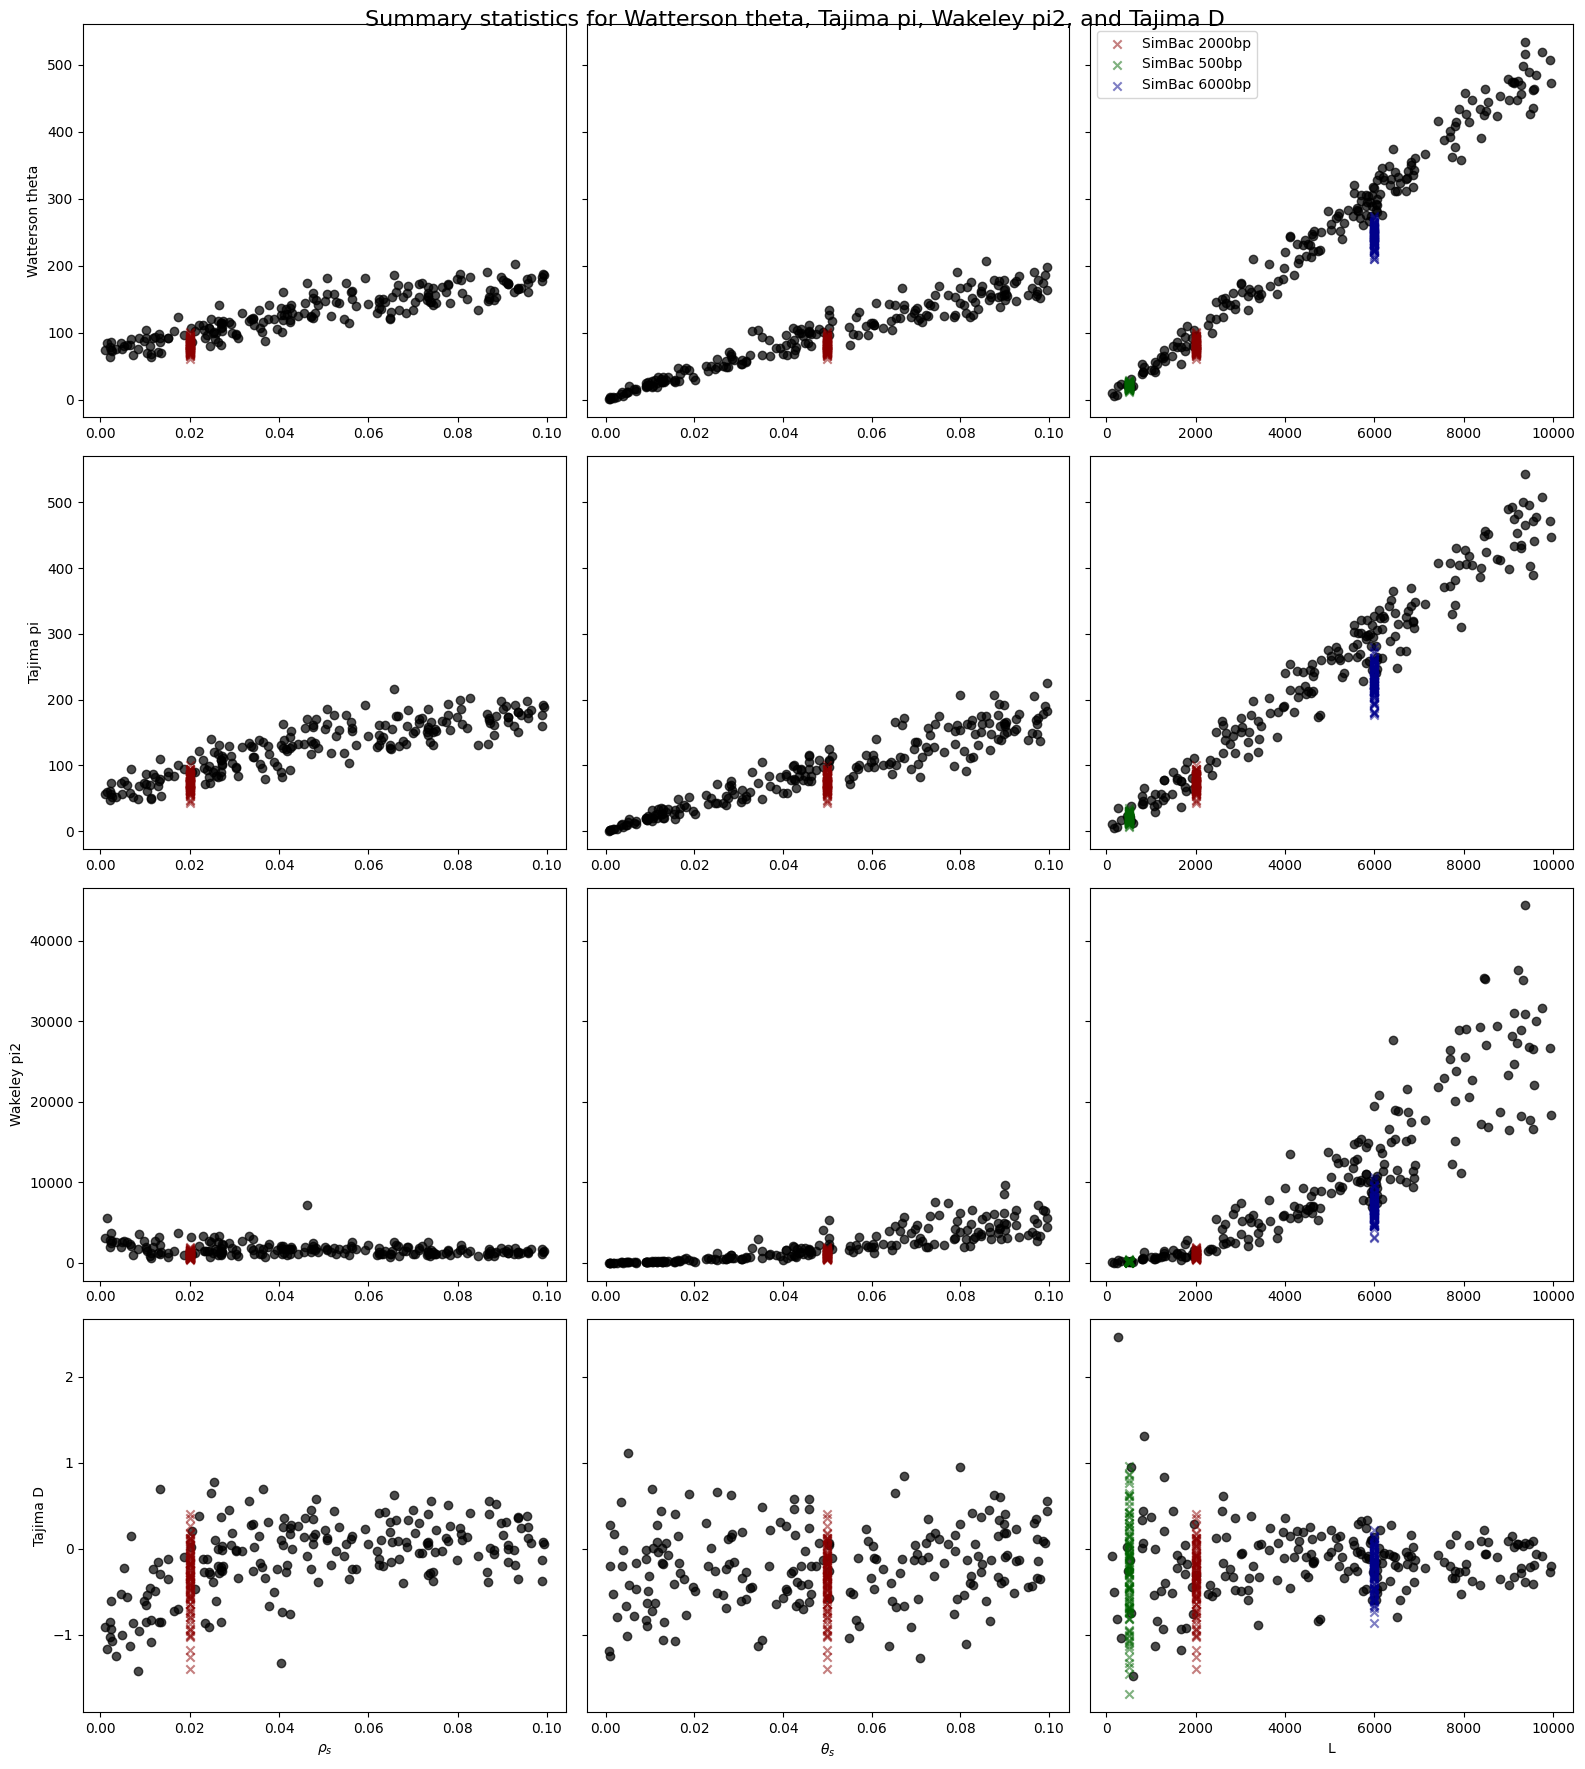

In [12]:
fig, axs = plt.subplots(4, 3, figsize=(16, 18), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(4):
        axs[row, col].scatter(x_var, y_mat[:, row+34], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+34], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(4):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+34], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+34], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)


axs[0, 0].set_ylabel('Watterson theta')
axs[1, 0].set_ylabel('Tajima pi')
axs[2, 0].set_ylabel('Wakeley pi2')
axs[3, 0].set_ylabel('Tajima D')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for Watterson theta, Tajima pi, Wakeley pi2, and Tajima D', fontsize=16)
plt.tight_layout()
plt.show()

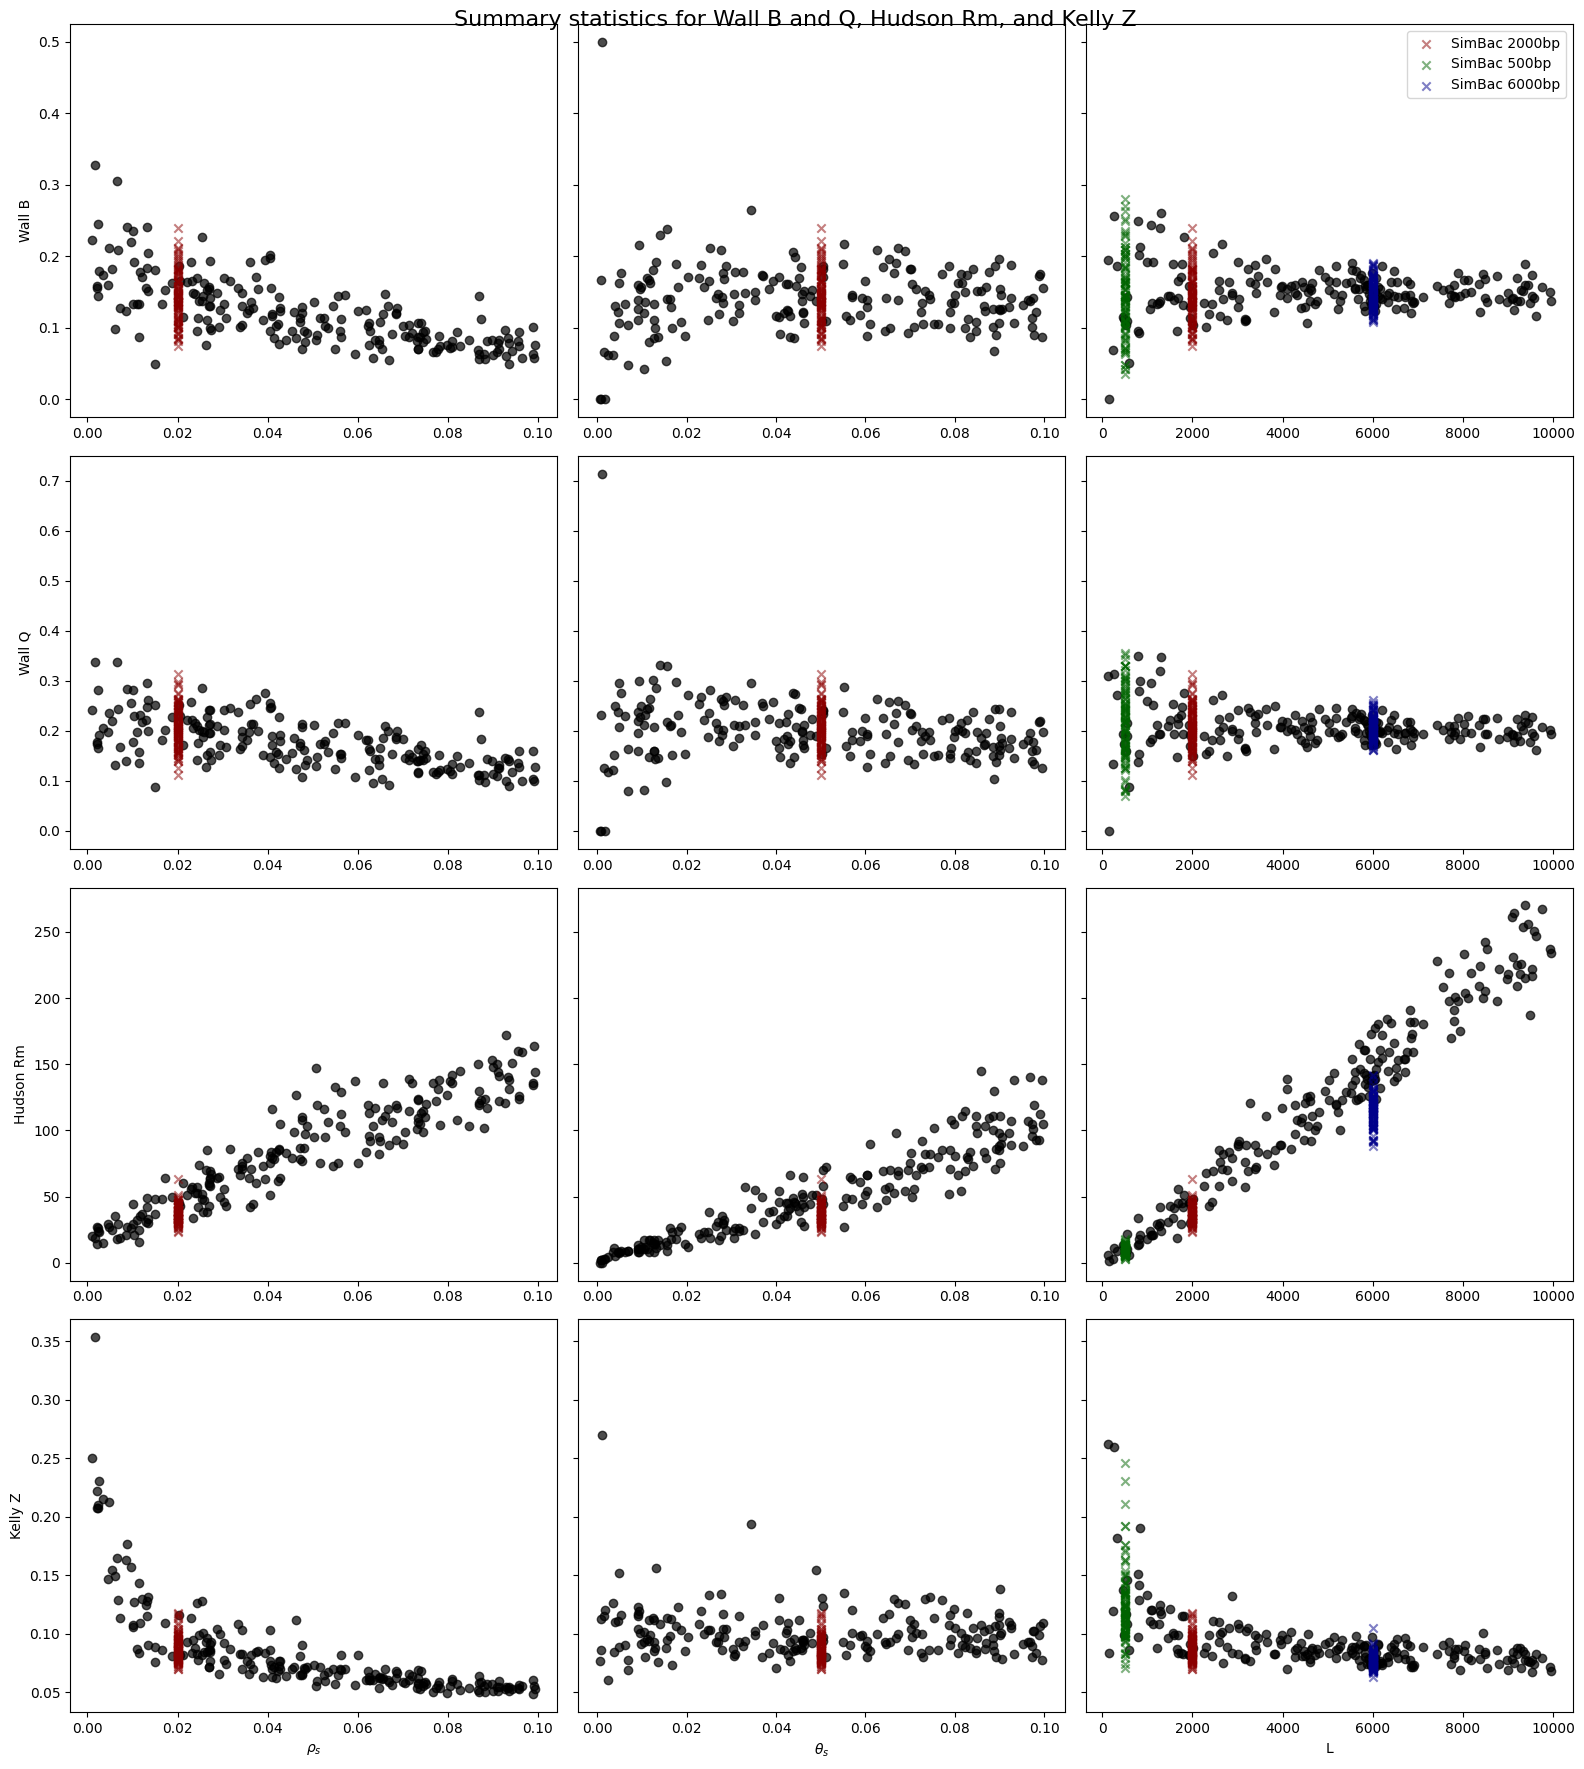

In [13]:
fig, axs = plt.subplots(4, 3, figsize=(16, 18), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(4):
        axs[row, col].scatter(x_var, y_mat[:, row+38], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+38], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[3, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(4):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+38], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+38], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('Wall B')
axs[1, 0].set_ylabel('Wall Q')
axs[2, 0].set_ylabel('Hudson Rm')
axs[3, 0].set_ylabel('Kelly Z')

axs[0, 2].legend(loc='best')

plt.suptitle('Summary statistics for Wall B and Q, Hudson Rm, and Kelly Z', fontsize=16)
plt.tight_layout()
plt.show()

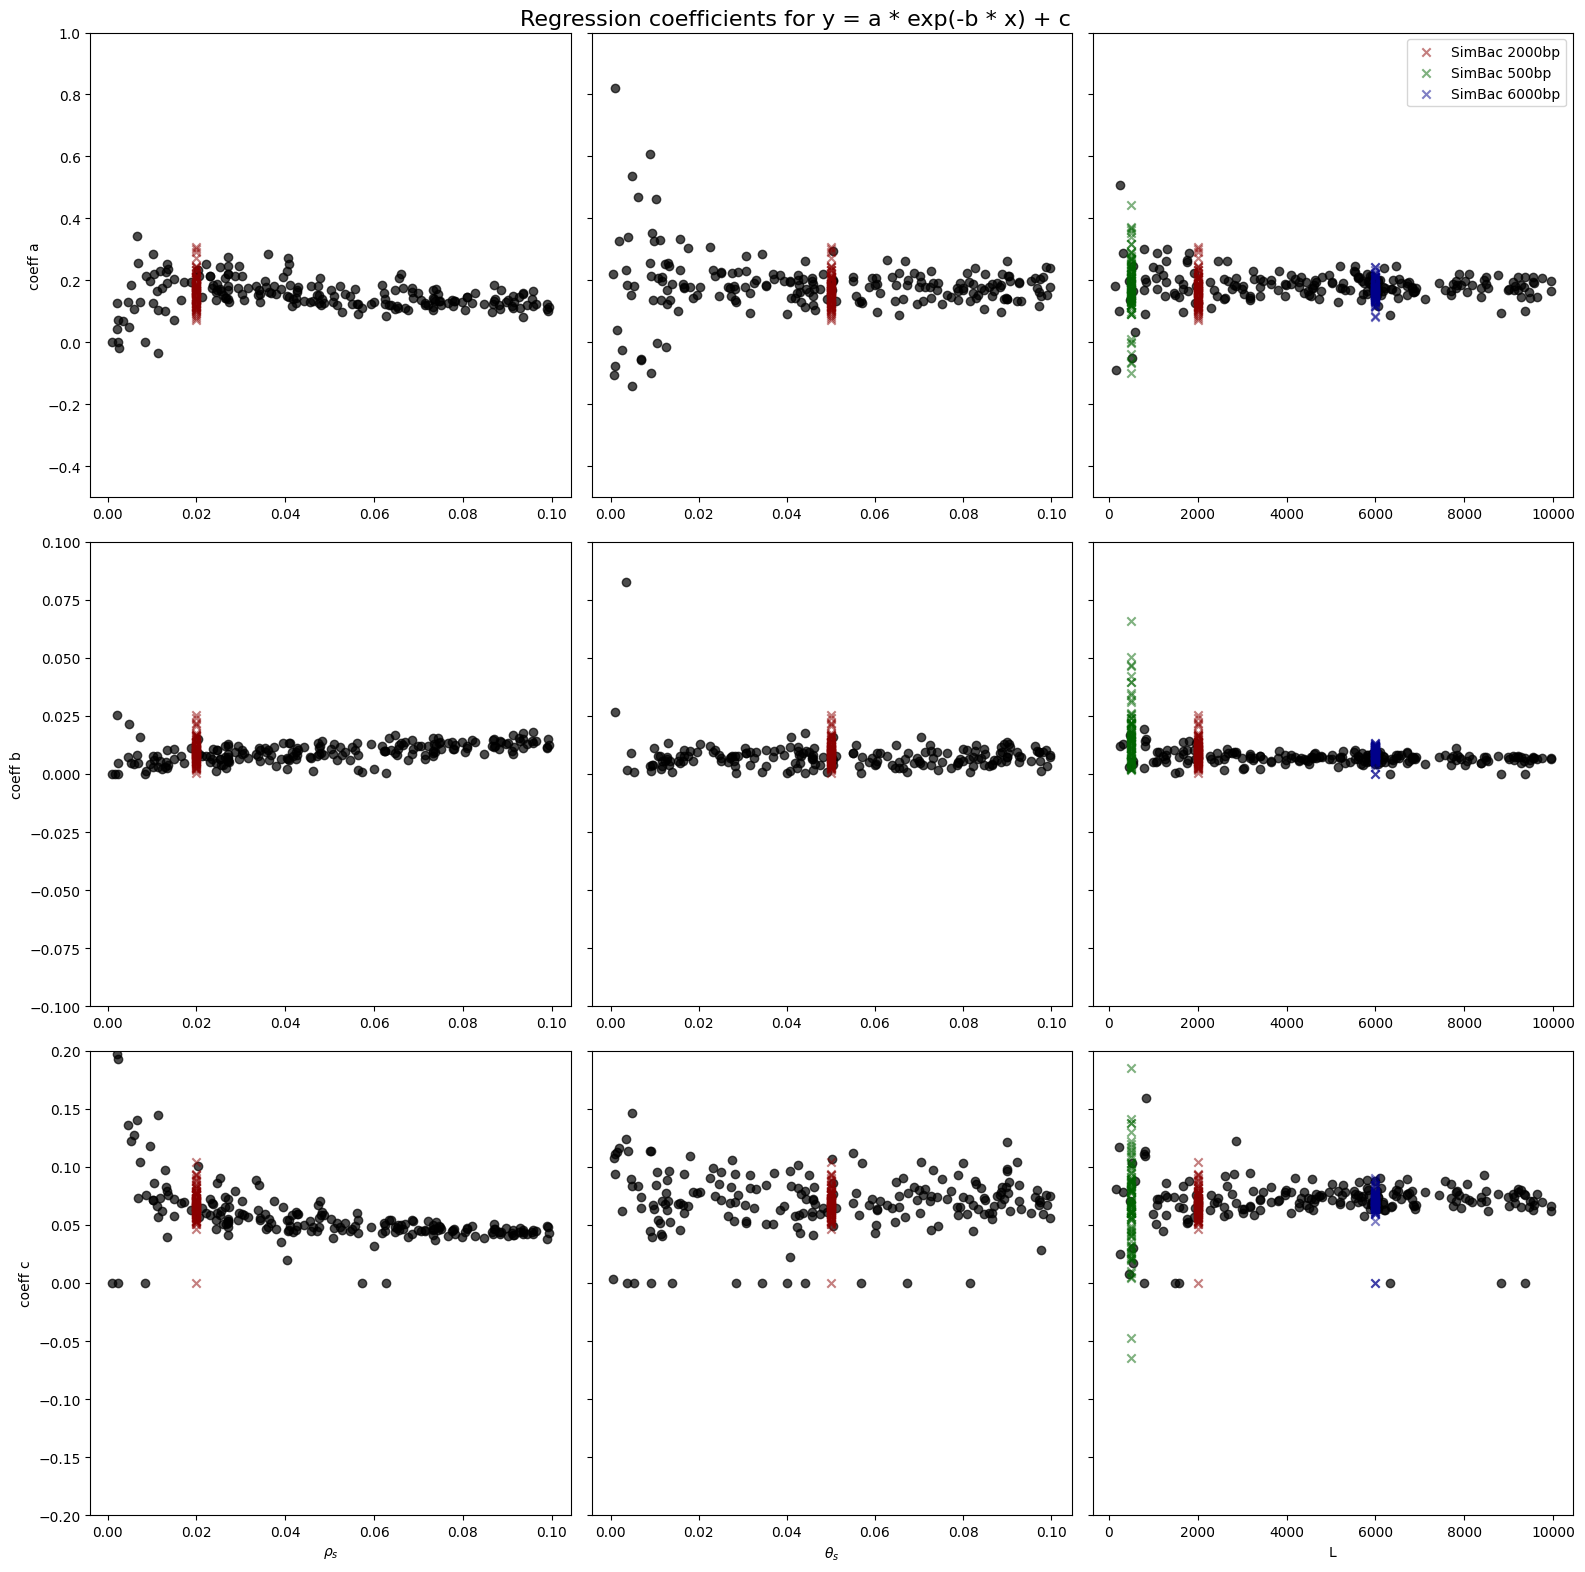

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(16, 16), sharey='row')

x_data = [x_seq[:, 0], x_seq[:, 2], x_seq[:, 3]]
true_x = [0.02, 0.05, 2000]
y_data_matrices = [rho_seq, theta_seq, L_seq]
x_labels = [r'$\rho_s$', r'$\theta_s$', "L"]

for col in range(3):
    x_var = x_data[col]
    fix_x = true_x[col]
    y_mat = y_data_matrices[col]

    for row in range(3):
        axs[row, col].scatter(x_var, y_mat[:, row+42], marker='o', color='black', alpha=0.7)
        axs[row, col].scatter(np.full(100, fix_x), x_2000_mat[:, row+42], marker='x', color='darkred', label = "SimBac 2000bp", alpha=0.5)

    axs[2, col].set_xlabel(x_labels[col])

    if col == 2:
        for row in range(3):
            axs[row, col].scatter(np.full(100, 500), x_500_mat[:, row+42], marker='x', color='darkgreen', label = "SimBac 500bp", alpha=0.5)
            axs[row, col].scatter(np.full(100, 6000), x_6000_mat[:, row+42], marker='x', color='darkblue', label = "SimBac 6000bp", alpha=0.5)

axs[0, 0].set_ylabel('coeff a')
axs[1, 0].set_ylabel('coeff b')
axs[2, 0].set_ylabel('coeff c')

axs[0, 0].set_ylim([-0.5, 1.0])
axs[1, 0].set_ylim([-0.1, 0.1])  
axs[2, 0].set_ylim([-0.2, 0.2])

axs[0, 2].legend(loc='best')

plt.suptitle('Regression coefficients for y = a * exp(-b * x) + c', fontsize=16)
plt.tight_layout()
plt.show()